# ArtBench-10 Student Starter Pack

This notebook is a starting template for class projects using **ArtBench-10**.

It covers:

1. Loading ArtBench-10 from the local folder `artbench_generative_suite/ArtBench-10`
2. Exploring dataset shape and class distribution
3. Building PyTorch dataloaders
4. Visualizing samples in a grid
5. Exporting samples to image files (one image per file)
6. Loading subset definitions from `training.csv` generated by `generate_training_csv.py`


## Dataset quick notes

- **Domain**: paintings / artistic styles
- **Classes**: 10 styles
- **Image size**: 32x32 RGB
- **Splits**: train and test

In this project setup, dataset files are expected in:

- `ArtBench-10/artbench-10-python/artbench-10-batches-py/`
- `ArtBench-10/ArtBench-10.csv`

If you do not have it on the folder, download from kaggle directly:

https://www.kaggle.com/datasets/alexanderliao/artbench10


In [28]:
from __future__ import annotations

import sys
import random
from pathlib import Path
import os
from collections import Counter

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt

from artbench_local_dataset import load_kaggle_artbench10_splits


In [29]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Relative paths (run this notebook from student_start_pack/)
PROJECT_ROOT = Path("..").resolve()
SCRIPTS_DIR = PROJECT_ROOT / 'scripts'
KAGGLE_ROOT = PROJECT_ROOT / 'ArtBench-10'

if not KAGGLE_ROOT.exists() or not (SCRIPTS_DIR / 'artbench_local_dataset.py').exists():
    raise FileNotFoundError(
        'Could not resolve project folders from relative paths. '
        'Run this notebook from student_start_pack/ or adjust PROJECT_ROOT.'
    )

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

print('PROJECT_ROOT =', PROJECT_ROOT)
print('KAGGLE_ROOT =', KAGGLE_ROOT)

PROJECT_ROOT = C:\Users\llara\OneDrive\Área de Trabalho\Universidade\Mestrado\Primeiro ano\Segundo Semestre\Inteligência Artificial Generativa\IAG
KAGGLE_ROOT = C:\Users\llara\OneDrive\Área de Trabalho\Universidade\Mestrado\Primeiro ano\Segundo Semestre\Inteligência Artificial Generativa\IAG\ArtBench-10


In [30]:
# Uses your existing project helper to load ArtBench-10 from local Kaggle-style files
hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_hf = hf_ds["train"]

print("Train size:", len(train_hf))
print("Columns   :", train_hf.column_names)

label_feature = train_hf.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)
print("Num classes:", num_classes)
print("Class names:", class_names)

Dataset source: kaggle root='C:\Users\llara\OneDrive\Área de Trabalho\Universidade\Mestrado\Primeiro ano\Segundo Semestre\Inteligência Artificial Generativa\IAG\ArtBench-10'
Train size: 50000
Columns   : ['image', 'label']
Num classes: 10
Class names: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


In [31]:
# Class distribution summary
train_counts = Counter(train_hf["label"])

print("\nTrain class distribution:")
for cid, name in enumerate(class_names):
    print(f"  {cid:2d} | {name:>15s} | {train_counts.get(cid, 0):6d}")


Train class distribution:
   0 |   impressionism |   5000
   1 |         realism |   5000
   2 |     romanticism |   5000
   3 |   expressionism |   5000
   4 |         baroque |   5000
   5 | post_impressionism |   5000
   6 |     art_nouveau |   5000
   7 |      surrealism |   5000
   8 |         ukiyo_e |   5000
   9 |     renaissance |   5000


## Build PyTorch datasets and dataloaders

You can change:

- `IMAGE_SIZE` (default 32)
- `BATCH_SIZE`
- `TRAIN_FRACTION` if you want to train on a subset

In [32]:
IMAGE_SIZE = 32
BATCH_SIZE = 64
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)
TRAIN_FRACTION = 1.0  # Example: 0.5 means half of train split

transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),  # outputs [0,1]
])


class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform else img
        return x, y, real_idx


def make_subset_indices(n_total: int, fraction: float, seed: int = 42):
    n_keep = max(1, int(round(n_total * fraction)))
    g = np.random.RandomState(seed)
    idx = np.arange(n_total)
    g.shuffle(idx)
    return idx[:n_keep].tolist()


train_indices = make_subset_indices(len(train_hf), TRAIN_FRACTION, seed=SEED)

train_ds = HFDatasetTorch(train_hf, transform=transform, indices=train_indices)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Train dataset length (after fraction):", len(train_ds))
print("Train batches                        :", len(train_loader))

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.
Train dataset length (after fraction): 50000
Train batches                        : 782


## Load subset of 20% samples `training_20_percent.csv` 

you can reproduce the same subset in this notebook by loading IDs from that CSV.

Use `train_id_original` for indexing this notebook's full train split.


In [34]:
import csv

#warning if using colab kernel on vscode you need to put the files on your google drive and link this notebook to it.
TRAINING_CSV_PATH = Path('training_20_percent.csv')
INDEX_COLUMN = 'train_id_original'  # recommended 


def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(
            f"training.csv not found: {csv_path}\n"
            "Generate it first with scripts/generate_training_csv.py"
        )

    ids = []
    with open(csv_path, 'r', encoding='utf-8', newline='') as f:
        r = csv.DictReader(f)
        if index_column not in (r.fieldnames or []):
            raise ValueError(
                f"Column {index_column!r} not present in {csv_path}. "
                f"Available: {r.fieldnames}"
            )
        for row in r:
            v = str(row.get(index_column, "")).strip()
            if v == "":
                continue
            ids.append(int(v))

    if len(ids) == 0:
        raise ValueError(f"No ids found in {csv_path} column {index_column!r}")
    return ids


train_ids_from_csv = load_ids_from_training_csv(TRAINING_CSV_PATH, index_column=INDEX_COLUMN)
print('Loaded ids:', len(train_ids_from_csv))
print('First 10 ids:', train_ids_from_csv[:10])

# Build a train dataset/loader using exactly those IDs
train_ds_from_csv = HFDatasetTorch(train_hf, transform=transform, indices=train_ids_from_csv)
train_loader_from_csv = DataLoader(
    train_ds_from_csv,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print('Subset train dataset length:', len(train_ds_from_csv))
print('Subset train batches      :', len(train_loader_from_csv))


Loaded ids: 10000
First 10 ids: [33553, 9427, 199, 12447, 39489, 42724, 10822, 49498, 4144, 36958]
Subset train dataset length: 10000
Subset train batches      : 157


## Visualize a sample grid

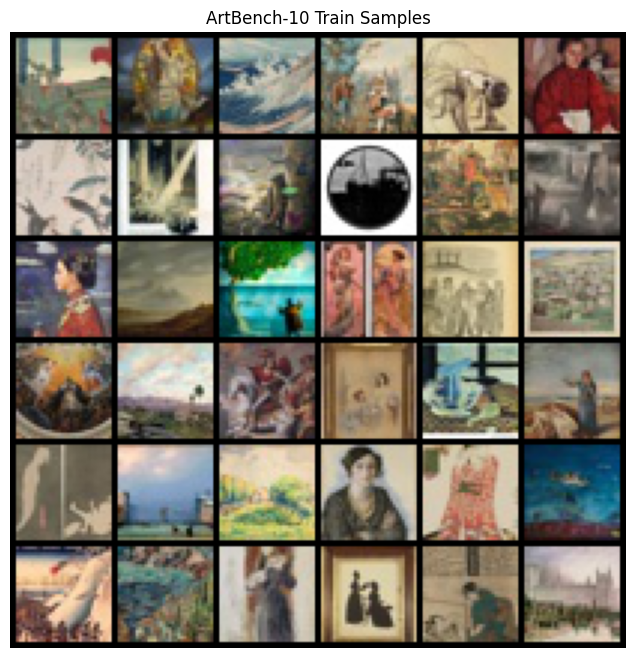

Labels: ['ukiyo_e', 'surrealism', 'ukiyo_e', 'realism', 'impressionism', 'art_nouveau', 'ukiyo_e', 'art_nouveau', 'surrealism', 'art_nouveau', 'post_impressionism', 'surrealism', 'impressionism', 'baroque', 'surrealism', 'art_nouveau', 'art_nouveau', 'art_nouveau', 'baroque', 'impressionism', 'baroque', 'romanticism', 'expressionism', 'romanticism', 'ukiyo_e', 'realism', 'post_impressionism', 'art_nouveau', 'ukiyo_e', 'surrealism', 'ukiyo_e', 'expressionism', 'impressionism', 'romanticism', 'ukiyo_e', 'romanticism']


In [36]:
def show_batch_grid(loader, class_names, n_images=36, nrow=6, title='Sample Grid'):
    x, y, idx = next(iter(loader))
    x = x[:n_images]
    y = y[:n_images]

    grid = make_grid(x, nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(np_img)
    plt.axis('off')
    plt.title(title)
    plt.show()

    # Print labels for quick inspection
    labels_str = [class_names[int(v)] for v in y]
    print('Labels:', labels_str)


show_batch_grid(train_loader, class_names, n_images=36, nrow=6, title='ArtBench-10 Train Samples')

## Export samples to image files

This helper saves one PNG per sample and writes a CSV with metadata.
Useful for qualitative analysis or external metric tools.

In [37]:
import csv


def export_split_to_folder(
    loader: DataLoader,
    class_names: list[str],
    out_dir: Path,
    max_images: int | None = 500,
):
    out_dir = Path(out_dir)
    img_dir = out_dir / 'images'
    img_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    saved = 0

    for x, y, idx in loader:
        b = x.shape[0]
        for i in range(b):
            if max_images is not None and saved >= max_images:
                break

            label_id = int(y[i].item())
            label_name = class_names[label_id]
            src_idx = int(idx[i].item())

            file_name = f"img_{saved:06d}_label{label_id:02d}_idx{src_idx:06d}.png"
            path = img_dir / file_name
            save_image(x[i], path)

            rows.append({
                'file_name': file_name,
                'label_id': label_id,
                'label_name': label_name,
                'source_index': src_idx,
            })
            saved += 1

        if max_images is not None and saved >= max_images:
            break

    csv_path = out_dir / 'metadata.csv'
    with open(csv_path, 'w', encoding='utf-8', newline='') as f:
        w = csv.DictWriter(f, fieldnames=['file_name', 'label_id', 'label_name', 'source_index'])
        w.writeheader()
        w.writerows(rows)

    print(f'Exported {saved} images to: {img_dir}')
    print(f'Metadata CSV: {csv_path}')


EXPORT_ROOT = Path('exported_data')
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

export_split_to_folder(train_loader, class_names, EXPORT_ROOT / 'train_subset', max_images=500)


Exported 500 images to: exported_data\train_subset\images
Metadata CSV: exported_data\train_subset\metadata.csv


# Definição das Arquiteturas

In [38]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Variational Autoencoder (VAE)
class VAE(nn.Module):
    def __init__ (self, latent_dim=128):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1), nn.ReLU(),
            nn.Flatten(),
        )
        self.fc_mu = nn.Linear(64 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(64 * 8 * 8, latent_dim)
        self.decoder_input = nn.Linear(latent_dim, 64 * 8 * 8)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        encoded = self.encoder(x)
        mu, logvar = self.fc_mu(encoded), self.fc_logvar(encoded)
        z = self.reparameterize(mu, logvar)
        de_input = self.decoder_input(z).view(-1, 64, 8, 8)
        return self.decoder(de_input), mu, logvar

In [39]:
# Deep Convolutional GAN (DCGAN)

class Generator(nn.Module):
    def __init__(self, nz=100):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Input is nz, going into a convolution
            nn.ConvTranspose2d(nz, 256, 4, 1, 0, bias=False), 
            nn.BatchNorm2d(256), nn.ReLU(True),
            
            # State size: 256 x 4 x 4
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False), 
            nn.BatchNorm2d(128), nn.ReLU(True),
            
            # State size: 128 x 8 x 8
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False), 
            nn.BatchNorm2d(64), nn.ReLU(True),
            
            # State size: 64 x 16 x 16 -> Now reaching 32 x 32
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False), 
            nn.Tanh()
            # Final State size: 3 x 32 x 32
        )
    def forward(self, x): return self.main(x)
    
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 64, 3, 2, 1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 3, 2, 1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 3, 2, 1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, 4, 1, 0), # This reduces 4x4 to 1x1
            nn.LeakyReLU(0.2),
        )
        # We add a Flatten layer or do it in forward
        self.flatten = nn.Flatten() 
        self.fc = nn.Linear(512, 1) 
    
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.flatten(x) # Shape becomes [batch, 512]
        return self.fc(x).view(-1)

In [40]:
# Toy Diffusion (U-Net Simplificada)
class TinyUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.down = nn.Sequential(nn.Conv2d(3, 64, 3, padding=1), nn.ReLU())
        self.up = nn.Sequential(nn.Conv2d(64, 3, 3, padding=1))
    def forward(self, x, t): 
        return self.up(self.down(x))


# Ciclo de Treino

In [41]:
#Instanciação
model_vae = VAE()
netG, netD = Generator(), Discriminator()
model_diff = TinyUNet()

#Otimizadores
opt_vae = torch.optim.Adam(model_vae.parameters(), lr=1e-3)
optG = torch.optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))
optD = torch.optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_diff = torch.optim.Adam(model_diff.parameters(), lr=1e-3)

#Parâmetros de difusão
T = 100
betas = torch.linspace(1e-4, 0.02, T)
alphas_cumprod = torch.cumprod(1. - betas, dim=0)

def vae_loss_fn(recon_x, x, mu, logvar):
    BCE = F.mse_loss(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

criterion_gan = nn.BCEWithLogitsLoss()

epochs = 10
for epoch in range(epochs):
    for i, (real_imgs, labels, indices) in enumerate(train_loader):
        real_imgs = real_imgs
        b_size = real_imgs.size(0)

        # Treino VAE
        opt_vae.zero_grad()
        recon, mu, logvar = model_vae(real_imgs)
        loss_vae = vae_loss_fn(recon, real_imgs, mu, logvar)
        loss_vae.backward(); opt_vae.step()

        # Treino GAN
        optD.zero_grad()
        noise = torch.randn(b_size, 100, 1, 1)
        fake_imgs = netG(noise)

        real_out = netD(real_imgs)
        fake_out = netD(fake_imgs.detach())

        loss_D = criterion_gan(real_out, torch.ones(b_size)) + \
                    criterion_gan(fake_out, torch.zeros(b_size))
        loss_D.backward()
        optD.step()

        optG.zero_grad()
        loss_G = criterion_gan(netD(fake_imgs), torch.ones(b_size))
        loss_G.backward()
        optG.step()

        # Treino Difusão
        opt_diff.zero_grad()
        t = torch.randint(0, T, (b_size,)).long()
        noise_ref = torch.randn_like(real_imgs)
        x_noisy = torch.sqrt(alphas_cumprod[t].view(-1,1,1,1)) * real_imgs + \
                  torch.sqrt(1-alphas_cumprod[t].view(-1,1,1,1)) * noise_ref
        loss_diff = F.mse_loss(model_diff(x_noisy, t), noise_ref)
        loss_diff.backward(); opt_diff.step()
        
    print(f"Epoch {epoch} concluída.")

Epoch 0 concluída.
Epoch 1 concluída.
Epoch 2 concluída.
Epoch 3 concluída.
Epoch 4 concluída.
Epoch 5 concluída.
Epoch 6 concluída.
Epoch 7 concluída.
Epoch 8 concluída.
Epoch 9 concluída.


In [42]:
# Teste rápido
test_input = torch.randn(4, 3, 32, 32)
test_output = netD(test_input)
print(f"Shape de entrada: {test_input.shape}")
print(f"Shape de saída: {test_output.shape}")  # Deve ser torch.Size([4])

Shape de entrada: torch.Size([4, 3, 32, 32])
Shape de saída: torch.Size([4])


In [43]:
!pip install torchmetrics[image]

Defaulting to user installation because normal site-packages is not writeable


In [44]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model_vae = model_vae.to(device).eval()
netG = netG.to(device).eval()
netD = netD.to(device).eval()
model_diff = model_diff.to(device).eval()
alphas_cumprod = alphas_cumprod.to(device)
betas = betas.to(device)

Device: cpu


In [45]:
import torch

def to_01(x):
    """Converte tensor para [0,1]."""
    x = x.detach().cpu()
    if x.min() < 0:
        x = (x + 1.0) / 2.0
    return x.clamp(0, 1)

def to_uint8(x):
    """Converte [0,1] -> uint8."""
    x = to_01(x)
    return (x * 255.0).round().to(torch.uint8)

In [47]:
def collect_real_images(loader, n_samples=5000):
    imgs = []
    for batch in loader:
        x = batch[0]  # (images, labels, indices)
        imgs.append(to_uint8(x))
        total = sum(t.size(0) for t in imgs)
        if total >= n_samples:
            break
    imgs = torch.cat(imgs, dim=0)[:n_samples]
    return imgs

real_5000 = collect_real_images(train_loader, n_samples=5000)
print(real_5000.shape, real_5000.dtype)

torch.Size([5000, 3, 32, 32]) torch.uint8


In [48]:
@torch.no_grad()
def sample_vae(model, n_samples=5000, latent_dim=128, batch_size=256, device="cpu"):
    model.eval()
    outs = []
    for _ in range((n_samples + batch_size - 1) // batch_size):
        cur_bs = min(batch_size, n_samples - len(outs) * batch_size)
        z = torch.randn(cur_bs, latent_dim, device=device)
        x = model.decoder_input(z).view(-1, 64, 8, 8)
        x = model.decoder(x)
        outs.append(to_uint8(x))
    return torch.cat(outs, dim=0)[:n_samples]

vae_5000 = sample_vae(model_vae, n_samples=5000, latent_dim=128, batch_size=256, device=device)
print(vae_5000.shape)

torch.Size([5000, 3, 32, 32])


In [49]:
@torch.no_grad()
def sample_gan(netG, n_samples=5000, noise_dim=100, batch_size=256, device="cpu"):
    netG.eval()
    outs = []
    for _ in range((n_samples + batch_size - 1) // batch_size):
        cur_bs = min(batch_size, n_samples - len(outs) * batch_size)
        z = torch.randn(cur_bs, noise_dim, 1, 1, device=device)
        x = netG(z)
        outs.append(to_uint8(x))
    return torch.cat(outs, dim=0)[:n_samples]

gan_5000 = sample_gan(netG, n_samples=5000, noise_dim=100, batch_size=256, device=device)
print(gan_5000.shape)

torch.Size([5000, 3, 32, 32])


In [50]:
@torch.no_grad()
def sample_diffusion(model, n_samples=5000, img_size=32, channels=3, batch_size=128, device="cpu"):
    model.eval()
    outs = []

    alpha = 1.0 - betas
    alpha_bar = torch.cumprod(alpha, dim=0)

    for _ in range((n_samples + batch_size - 1) // batch_size):
        cur_bs = min(batch_size, n_samples - len(outs) * batch_size)

        x = torch.randn(cur_bs, channels, img_size, img_size, device=device)

        for t in reversed(range(T)):
            tt = torch.full((cur_bs,), t, device=device, dtype=torch.long)

            pred_noise = model(x, tt)

            a_t = alpha[t]
            ab_t = alpha_bar[t]
            b_t = betas[t]

            if t > 0:
                z = torch.randn_like(x)
            else:
                z = torch.zeros_like(x)

            x = (1 / torch.sqrt(a_t)) * (
                x - ((1 - a_t) / torch.sqrt(1 - ab_t)) * pred_noise
            ) + torch.sqrt(b_t) * z

        outs.append(to_uint8(x))

    return torch.cat(outs, dim=0)[:n_samples]

diff_5000 = sample_diffusion(model_diff, n_samples=5000, img_size=32, channels=3, batch_size=128, device=device)
print(diff_5000.shape)

torch.Size([5000, 3, 32, 32])


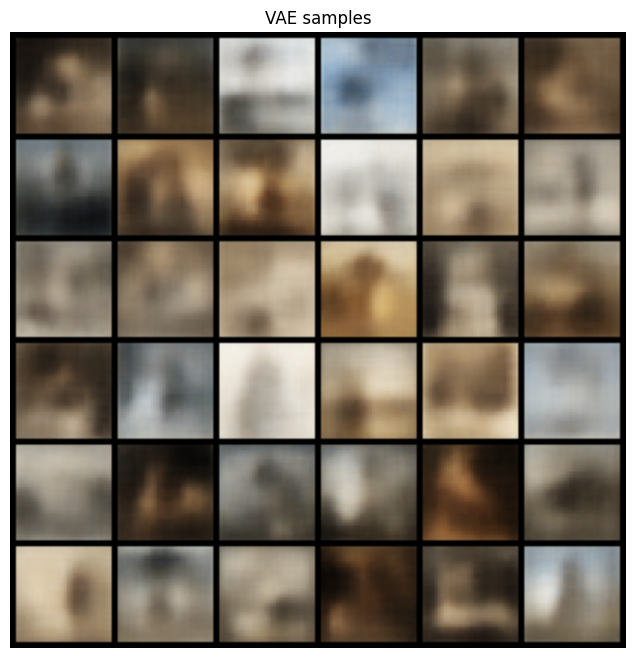

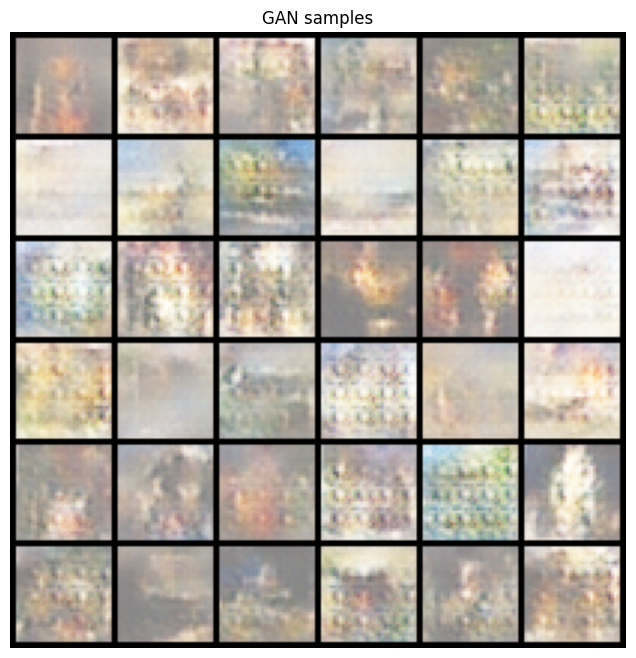

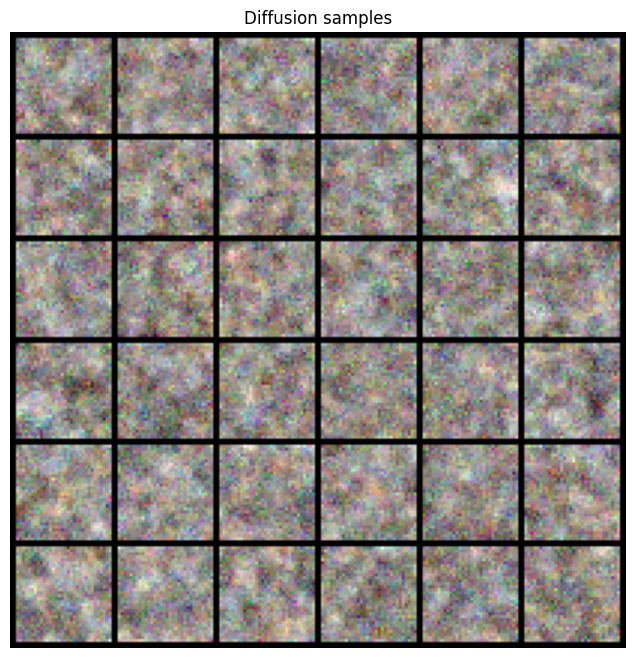

In [51]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

def show_generated_grid(images_uint8, title, n=36, nrow=6):
    x = images_uint8[:n].float() / 255.0
    grid = make_grid(x, nrow=nrow, padding=2)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.axis("off")
    plt.title(title)
    plt.show()

show_generated_grid(vae_5000, "VAE samples")
show_generated_grid(gan_5000, "GAN samples")
show_generated_grid(diff_5000, "Diffusion samples")

In [52]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance

def compute_fid_kid(real_uint8, fake_uint8, kid_subsets=50, kid_subset_size=100, device="cpu"):
    fid = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
    kid = KernelInceptionDistance(
        feature=2048,
        subsets=kid_subsets,
        subset_size=kid_subset_size,
        normalize=False
    ).to(device)

    real = real_uint8.to(device)
    fake = fake_uint8.to(device)

    fid.update(real, real=True)
    fid.update(fake, real=False)
    fid_score = float(fid.compute().cpu())

    kid.update(real, real=True)
    kid.update(fake, real=False)
    kid_mean, kid_std = kid.compute()

    return fid_score, float(kid_mean.cpu()), float(kid_std.cpu())

In [1]:
results = {}

for name, fake_imgs in {
    "VAE": vae_5000,
    "DCGAN": gan_5000,
    "Diffusion": diff_5000,
}.items():
    fid_score, kid_mean, kid_std = compute_fid_kid(
        real_5000, fake_imgs,
        kid_subsets=50,
        kid_subset_size=100,
        device=device
    )
    results[name] = {
        "FID": fid_score,
        "KID_mean": kid_mean,
        "KID_std": kid_std
    }

results

NameError: name 'vae_5000' is not defined